In [1]:
import numpy as np 
import matplotlib.pyplot as plt 

Question 1

In [2]:
def func_y(y,t):
    exp = -y + np.exp(t)
    return exp 

def runga_4_kutta(y,t,h):
    k1 = func_y(y,t)
    k2 = func_y((y+(k1/2)*h),(t+(h/2)))
    k3 = func_y((y+(k2/2)*h),(t+(h/2)))
    k4 = func_y((y+(k3*h)),(t+h))

    y_new = y + ((h/6)*(k1 + 2*k2 + 2*k3 + k4 ))

    return y_new

def adam_bash_4(y0,t_start,t_end,h):
    y=[y0]
    t=[t_start]
    f=[func_y(y0,t_start)]
    
    nodes = int((t_end - t_start)/h)
    
    for i in range(3):
        y_new = runga_4_kutta(y[i],t[i],h)
        t_new = t[i]+h
        f_new = func_y(y_new,t_new)

        y.append(y_new)
        t.append(t_new)
        f.append(f_new)

    for i in range(3,nodes):
        y_new = y[i] + (h/24)*(55*f[i] - 59*f[i-1] + 37*f[i-2] -9*f[i-3])
        t_new = t[i]+h
        f_new = func_y(y_new,t_new)

        y.append(y_new)
        f.append(f_new)
        t.append(t_new)

    # Print results nicely
    #print("t".ljust(8), "y (approx)".ljust(15), "exact y=cosh(t)".ljust(15), "error")
    print("t".ljust(8), "y (approx)".ljust(15))
    for ti, yi in zip(t, y):
        #exact = np.cosh(ti)
        #print(f"{ti:6.2f}  {yi:12.9f}  {exact:12.9f}  {abs(exact - yi):.2e}")
        print(f"{ti:6.2f}  {yi:12.9f}")

    return np.array(t), np.array(y)
h = [0.1, 0.2]
t_start = 0
t_end = 1
y_start = 1
for i in h:
    adam_bash_4(y_start,t_start, t_end, i)
    

t        y (approx)     
  0.00   1.000000000
  0.10   1.005004291
  0.20   1.020066994
  0.30   1.045338863
  0.40   1.081071997
  0.50   1.127624686
  0.60   1.185462681
  0.70   1.255165008
  0.80   1.337429224
  0.90   1.433078710
  1.00   1.543070757
t        y (approx)     
  0.00   1.000000000
  0.20   1.020070716
  0.40   1.081079932
  0.60   1.185476257
  0.80   1.337398626
  1.00   1.542994330


Question 2 

C:\Users\mital\AppData\Local\Temp\ipykernel_12676\4054290705.py:20: RuntimeWarning: overflow encountered in sinh
  return np.array([dPsi, np.sinh(Psi)])



======== Shooting Method (Considering BOTH BCs) ========

Iteration 1:
  s1=-0.1000000000,  Error1=1.2841624363e+09
  s2=-1.0000000000,  Error2=1.3149495775e+01
  New slope guess = -1.0000000092
  Boundary Psi=5.0098965858e+00, Psi'=1.2157703114e+01
  Combined error=1.3149479412e+01

Iteration 2:
  s1=-1.0000000000,  Error1=1.3149495775e+01
  s2=-1.0000000092,  Error2=1.3149479412e+01
  New slope guess = -1.0074059763
  Boundary Psi=3.4560568657e+00, Psi'=5.4453672420e+00
  Combined error=6.4495235063e+00

Iteration 3:
  s1=-1.0000000092,  Error1=1.3149479412e+01
  s2=-1.0074059763,  Error2=6.4495235063e+00
  New slope guess = -1.0145351215
  Boundary Psi=2.4964084336e+00, Psi'=3.1881528804e+00
  Combined error=4.0492436153e+00

Iteration 4:
  s1=-1.0074059763,  Error1=6.4495235063e+00
  s2=-1.0145351215,  Error2=4.0492436153e+00
  New slope guess = -1.0265619046
  Boundary Psi=1.2919604437e+00, Psi'=1.3719749080e+00
  Combined error=1.8845362656e+00

Iteration 5:
  s1=-1.0145351215, 

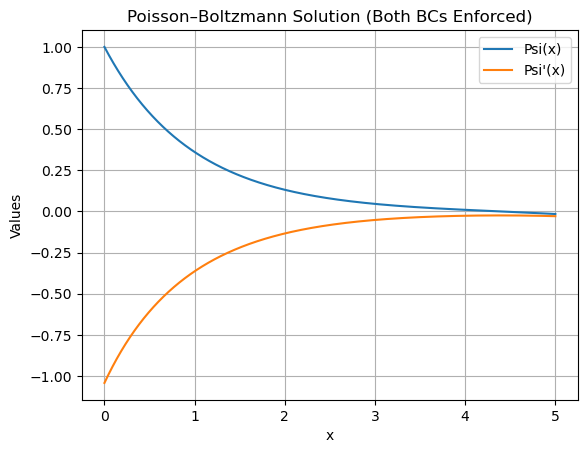

In [ ]:
def rk4_step(f, x, y, h):
    k1 = f(x, y)
    k2 = f(x + h/2, y + h*k1/2)
    k3 = f(x + h/2, y + h*k2/2)
    k4 = f(x + h,   y + h*k3)
    return y + (h/6)*(k1 + 2*k2 + 2*k3 + k4)

# ----------------------------------------------------------
# System of 1st-order ODEs
# y = [Psi, Psi']
# ----------------------------------------------------------
def system(x, y):
    Psi, dPsi = y
    return np.array([dPsi, np.sinh(Psi)])

# ----------------------------------------------------------
# Integrate ODE for a given slope s = Psi'(0)
# ----------------------------------------------------------
def shoot(s, xmax=5, h=0.001, verbose=False):

    x_vals = np.arange(0, xmax+h, h)
    y = np.array([1.0, s])     # [Psi(0), Psi'(0)]
    Psi_list = []
    dPsi_list = []

    for x in x_vals:
        Psi_list.append(y[0])
        dPsi_list.append(y[1])

        if verbose:
            print(f"x={x:.4f}, Psi={y[0]:.8f}, Psi'={y[1]:.8f}")

        y = rk4_step(system, x, y, h)

        # Avoid numerical blow-up
        if abs(y[0]) > 1e6:
            break

    return x_vals[:len(Psi_list)], np.array(Psi_list), np.array(dPsi_list)

# ----------------------------------------------------------
# Error function at boundary: sqrt(Psi^2 + Psi'^2)
# This enforces BOTH boundary conditions correctly.
# ----------------------------------------------------------
def boundary_error(Psi_end, dPsi_end):
    return np.sqrt(Psi_end**2 + dPsi_end**2)

# ----------------------------------------------------------
# Shooting method using secant method on the boundary error
# ----------------------------------------------------------
def find_slope(xmax=5, h=0.001):

    # two initial guesses
    s1 = -0.1
    s2 = -1.0

    _, Psi1, dPsi1 = shoot(s1, xmax, h)
    _, Psi2, dPsi2 = shoot(s2, xmax, h)

    F1 = boundary_error(Psi1[-1], dPsi1[-1])
    F2 = boundary_error(Psi2[-1], dPsi2[-1])

    print("\n======== Shooting Method (Considering BOTH BCs) ========")

    for it in range(50):

        print(f"\nIteration {it+1}:")
        print(f"  s1={s1:.10f},  Error1={F1:.10e}")
        print(f"  s2={s2:.10f},  Error2={F2:.10e}")

        s_new = s2 - F2 * (s2 - s1) / (F2 - F1)
        print(f"  New slope guess = {s_new:.10f}")

        # shift slopes
        s1, s2 = s2, s_new

        # compute new solution
        _, Psi2, dPsi2 = shoot(s2, xmax, h)

        # new error
        F1, F2 = F2, boundary_error(Psi2[-1], dPsi2[-1])

        print(f"  Boundary Psi={Psi2[-1]:.10e}, Psi'={dPsi2[-1]:.10e}")
        print(f"  Combined error={F2:.10e}")

        if F2 < 1e-10:
            print("\nConverged!")
            break

    return s2

# ----------------------------------------------------------
# Solve the entire problem
# ----------------------------------------------------------
xmax = 5
h = 0.001

s_opt = find_slope(xmax, h)
print("\nOptimal slope Psi'(0) =", s_opt)

# Integrate with optimal slope
x, Psi, dPsi = shoot(s_opt, xmax, h)

# ----------------------------------------------------------
# Plot Psi
# ----------------------------------------------------------
plt.plot(x, Psi, label="Psi(x)")
plt.plot(x, dPsi, label="Psi'(x)")
plt.title("Poisson–Boltzmann Solution (Both BCs Enforced)")
plt.xlabel("x")
plt.ylabel("Values")
plt.grid(True)
plt.legend()
plt.show()


Quiz Solution

In [4]:
def new_func(x,y):
    exp = y - (x**2) + 1
    #exp = x-(y**2)
    return exp 

def rk_2 (x,y,h):
    k1 = h *new_func(x,y)
    k2 = h * new_func((x+h) ,(y+k1))
    y_new = y + ((k1+k2)/2)
    return y_new

def adam_bash_4(x0,y0,h):
    x=[x0]
    y=[y0]
    f=[new_func(x0,y0)]

    y1 = rk_2(x0,y0,h)
    x1 = x0 + h
    x.append(x1)
    y.append(y1)
    new_f = new_func(x1, y1)
    f.append(new_f)

    y2 = y1 + ((h/2)*(3*f[1]-f[0]))
    return y2

case1 = adam_bash_4(0, 2, 0.1)
print(f"The value of y2 for y(0)=2 is {case1}")
case2 = adam_bash_4(0, 1.5, 0.1)
print(f"The value of y2 for y(0)=1.5 is {case2}")
case3 = adam_bash_4(0, 2, 0.2)
print(f"The value of y2 for y(0)=2 is {case3}")
case4 = adam_bash_4(0, 2, 0.15)
print(f"The value of y2 for y(0)=2 is {case4}")

The value of y2 for y(0)=2 is 2.6601749999999997
The value of y2 for y(0)=1.5 is 2.0498
The value of y2 for y(0)=2 is 3.4408000000000003
The value of y2 for y(0)=2 is 3.0354640625
